# Step 2: Exploratory Data Analysis

Before fitting any model, we thoroughly explore the simulated data to verify:
1. Shape and structure are as expected
2. Designation patterns match ground truth
3. Team-level variation is visible
4. Monthly counts are stable (no spurious trends)
5. Poisson assumption is reasonable (mean ≈ variance per group)

If anything looks surprising here, we fix the simulation — not the model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

# Ground truth (for reference lines in plots)
MU_ORG             = np.log(8)
DESIGNATIONS       = ['aSDE', 'SDE-1', 'SDE-2', 'SDE-3', 'SDE-4']
TRUE_DESIG_OFFSETS = np.array([-0.2, 0.3, 0.2, -0.3, -0.7])
TRUE_LAM_PER_DESIG = np.exp(MU_ORG + TRUE_DESIG_OFFSETS)

df = pd.read_csv('../../data/pr_simulated.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(8)

Shape: (1896, 10)
Columns: ['developer_id', 'month', 'designation', 'desig_id', 'team', 'team_id', 'tier', 'true_lam', 'exposure', 'pr_count']


,developer_id,month,designation,desig_id,team,team_id,tier,true_lam,exposure,pr_count
0,0,1,aSDE,0,Team-1,0,balanced,10.316876,1.0,13
1,0,2,aSDE,0,Team-1,0,balanced,10.316876,1.0,6
2,0,3,aSDE,0,Team-1,0,balanced,10.316876,1.0,12
3,0,4,aSDE,0,Team-1,0,balanced,10.316876,1.0,11
4,0,5,aSDE,0,Team-1,0,balanced,10.316876,1.0,14
5,0,6,aSDE,0,Team-1,0,balanced,10.316876,1.0,10
6,1,1,aSDE,0,Team-1,0,balanced,11.830116,1.0,10
7,1,2,aSDE,0,Team-1,0,balanced,11.830116,1.0,15


## 1. Basic Structure Checks

In [2]:
print("=" * 50)
print("BASIC STRUCTURE")
print("=" * 50)

print(f"\nTotal rows          : {len(df)}")
print(f"Unique developers   : {df['developer_id'].nunique()}")
print(f"Unique months       : {df['month'].nunique()}  → {sorted(df['month'].unique())}")
print(f"Unique teams        : {df['team'].nunique()}")
print(f"Unique designations : {df['designation'].nunique()}")

print(f"\nRows per developer  : {df.groupby('developer_id').size().unique()} (should all be 6)")
print(f"Exposure values     : {df['exposure'].unique()} (should all be 1.0)")
print(f"Any missing values  : {df.isnull().sum().sum()}")
print(f"Any negative counts : {(df['pr_count'] < 0).sum()}")

print("\nDeveloper count per designation:")
print(df.drop_duplicates('developer_id')['designation']
        .value_counts()
        .reindex(DESIGNATIONS))

BASIC STRUCTURE

Total rows          : 1896
Unique developers   : 316
Unique months       : 6  → [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Unique teams        : 15
Unique designations : 5

Rows per developer  : [6] (should all be 6)
Exposure values     : [1.] (should all be 1.0)
Any missing values  : 0
Any negative counts : 0

Developer count per designation:
designation
aSDE     108
SDE-1     82
SDE-2     63
SDE-3     42
SDE-4     21
Name: count, dtype: int64


## 2. Overall PR Count Distribution

Check: Poisson-shaped (right-skewed, no hard boundary), mean ≈ variance.

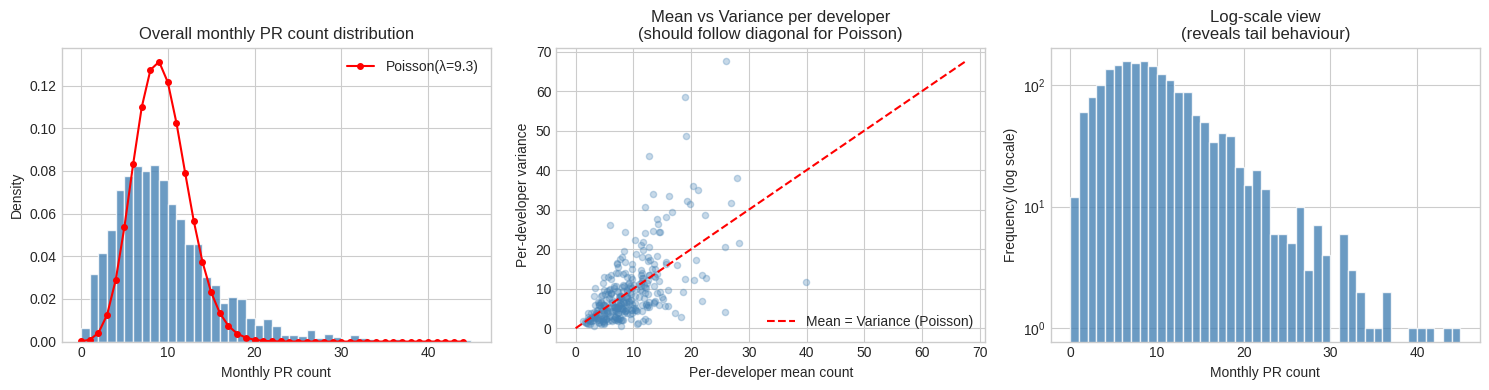

Overall mean    : 9.270
Overall variance: 35.827
Ratio var/mean  : 3.865  (should be ≈ 1 for Poisson)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: Histogram of monthly counts
ax = axes[0]
counts = df['pr_count']
bins = range(0, counts.max() + 2)
ax.hist(counts, bins=bins, color='steelblue', alpha=0.8, edgecolor='white', density=True)

# Overlay Poisson(mean) for comparison
lam_fit = counts.mean()
x = np.arange(0, counts.max() + 1)
ax.plot(x, stats.poisson.pmf(x, lam_fit), 'r-o', ms=4, lw=1.5,
        label=f'Poisson(λ={lam_fit:.1f})')
ax.set_xlabel("Monthly PR count")
ax.set_ylabel("Density")
ax.set_title("Overall monthly PR count distribution")
ax.legend()

# Panel 2: Mean vs Variance per developer (Poisson check)
ax = axes[1]
dev_stats = df.groupby('developer_id')['pr_count'].agg(['mean', 'var'])
ax.scatter(dev_stats['mean'], dev_stats['var'], alpha=0.3, s=20, color='steelblue')
max_val = max(dev_stats['mean'].max(), dev_stats['var'].max())
ax.plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Mean = Variance (Poisson)')
ax.set_xlabel("Per-developer mean count")
ax.set_ylabel("Per-developer variance")
ax.set_title("Mean vs Variance per developer\n(should follow diagonal for Poisson)")
ax.legend()

# Panel 3: Log-scale histogram
ax = axes[2]
ax.hist(counts, bins=bins, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_yscale('log')
ax.set_xlabel("Monthly PR count")
ax.set_ylabel("Frequency (log scale)")
ax.set_title("Log-scale view\n(reveals tail behaviour)")

plt.tight_layout()
plt.show()

print(f"Overall mean    : {counts.mean():.3f}")
print(f"Overall variance: {counts.var():.3f}")
print(f"Ratio var/mean  : {counts.var()/counts.mean():.3f}  (should be ≈ 1 for Poisson)")

## 3. Designation-Level Patterns

Check: means match `exp(MU_ORG + TRUE_DESIG_OFFSETS)` within sampling noise.

/tmp/ipykernel_1880293/782818323.py:36: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/satishthakur/codebase/data-science/statistics/bayes-bda-rethinking/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


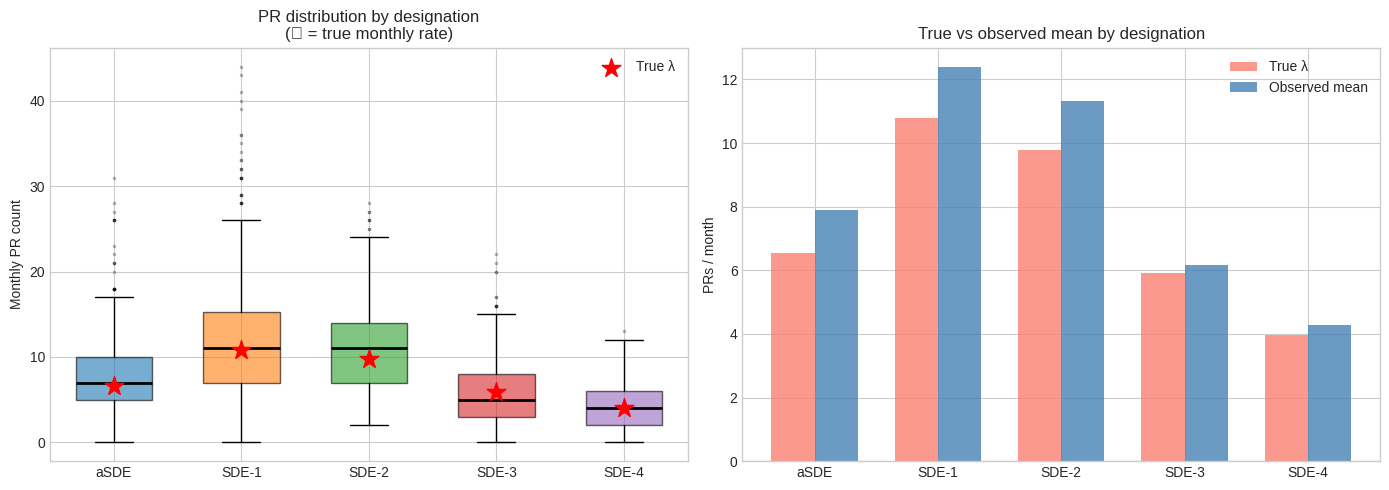


Designation-level summary (monthly counts):
               mean  median    std     var  true_lam  var/mean
designation                                                   
aSDE          7.889     7.0  4.437  19.691     6.550     2.496
SDE-1        12.376    11.0  7.331  53.750    10.799     4.343
SDE-2        11.320    11.0  5.197  27.009     9.771     2.386
SDE-3         6.167     5.0  4.238  17.964     5.927     2.913
SDE-4         4.294     4.0  2.757   7.601     3.973     1.770


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Boxplot by designation
ax = axes[0]
for i, desig in enumerate(DESIGNATIONS):
    vals = df[df.designation == desig]['pr_count']
    ax.boxplot(vals, positions=[i], widths=0.6, patch_artist=True,
               boxprops=dict(facecolor=f'C{i}', alpha=0.6),
               medianprops=dict(color='black', lw=2),
               flierprops=dict(marker='.', markersize=3, alpha=0.3))
    ax.scatter(i, TRUE_LAM_PER_DESIG[i], marker='*', s=200,
               color='red', zorder=5, label='True λ' if i == 0 else '')
ax.set_xticks(range(len(DESIGNATIONS)))
ax.set_xticklabels(DESIGNATIONS)
ax.set_ylabel("Monthly PR count")
ax.set_title("PR distribution by designation\n(★ = true monthly rate)")
ax.legend()

# Panel 2: Observed mean vs true lambda per designation
ax = axes[1]
obs_means = (df.groupby('designation')['pr_count']
               .mean()
               .reindex(DESIGNATIONS))
x = np.arange(len(DESIGNATIONS))
width = 0.35
ax.bar(x - width/2, TRUE_LAM_PER_DESIG, width, label='True λ',
       color='salmon', alpha=0.8)
ax.bar(x + width/2, obs_means.values, width, label='Observed mean',
       color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(DESIGNATIONS)
ax.set_ylabel("PRs / month")
ax.set_title("True vs observed mean by designation")
ax.legend()

plt.tight_layout()
plt.show()

# Numeric summary
summary = df.groupby('designation')['pr_count'].agg(['mean','median','std','var']).round(3)
summary.index = pd.CategoricalIndex(summary.index, categories=DESIGNATIONS, ordered=True)
summary = summary.sort_index()
summary['true_lam']  = TRUE_LAM_PER_DESIG.round(3)
summary['var/mean']  = (summary['var'] / summary['mean']).round(3)
print("\nDesignation-level summary (monthly counts):")
print(summary)

## 4. Team-Level Variation

Check: teams show visible differences, roughly `Normal(0, σ_team=0.3)` on log scale.

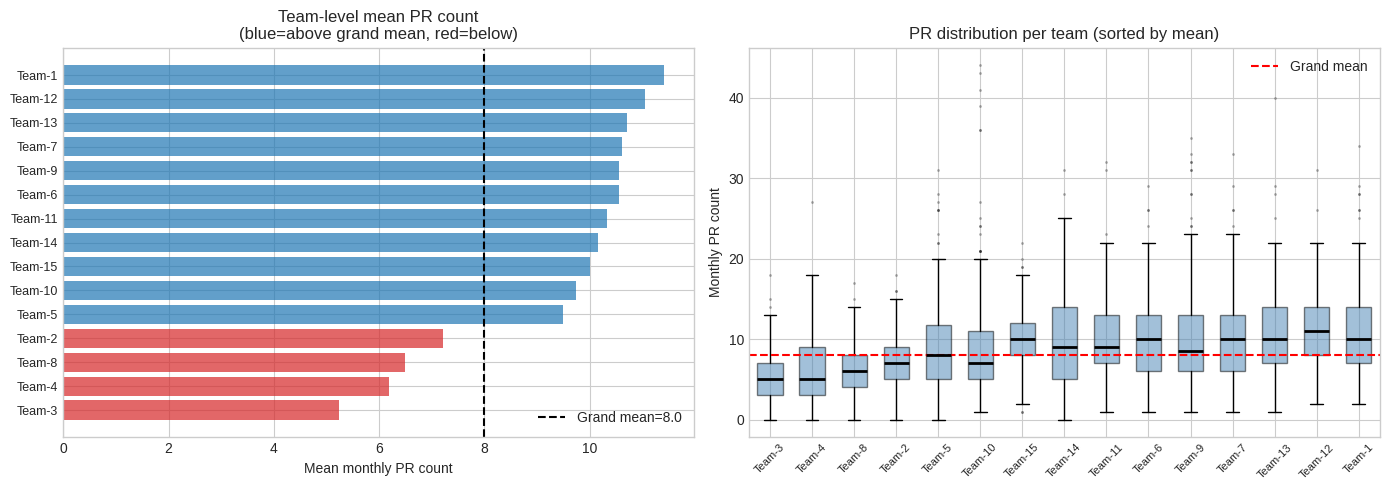

Team-level means and std devs:
          mean   std
team                
Team-3    5.24  3.41
Team-4    6.18  4.58
Team-8    6.50  3.31
Team-2    7.22  3.66
Team-5    9.49  6.27
Team-10   9.73  8.35
Team-15  10.01  4.14
Team-14  10.16  6.27
Team-11  10.32  5.59
Team-6   10.56  5.44
Team-9   10.56  7.49
Team-7   10.61  6.42
Team-13  10.72  5.72
Team-12  11.04  5.63
Team-1   11.41  5.97


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

team_order = (df.groupby('team')['pr_count']
                .mean()
                .sort_values()
                .index.tolist())

# Panel 1: Mean PR count per team (sorted)
ax = axes[0]
team_means = df.groupby('team')['pr_count'].mean().reindex(team_order)
colors = ['C0' if v >= np.exp(MU_ORG) else 'C3' for v in team_means]
ax.barh(range(len(team_order)), team_means.values, color=colors, alpha=0.7)
ax.axvline(np.exp(MU_ORG), color='black', linestyle='--', lw=1.5,
           label=f'Grand mean={np.exp(MU_ORG):.1f}')
ax.set_yticks(range(len(team_order)))
ax.set_yticklabels(team_order, fontsize=9)
ax.set_xlabel("Mean monthly PR count")
ax.set_title("Team-level mean PR count\n(blue=above grand mean, red=below)")
ax.legend()

# Panel 2: Boxplot per team
ax = axes[1]
for j, team in enumerate(team_order):
    vals = df[df.team == team]['pr_count']
    ax.boxplot(vals, positions=[j], widths=0.6, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.5),
               medianprops=dict(color='black', lw=2),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.axhline(np.exp(MU_ORG), color='red', linestyle='--', lw=1.5, label='Grand mean')
ax.set_xticks(range(len(team_order)))
ax.set_xticklabels(team_order, rotation=45, fontsize=8)
ax.set_ylabel("Monthly PR count")
ax.set_title("PR distribution per team (sorted by mean)")
ax.legend()

plt.tight_layout()
plt.show()

print("Team-level means and std devs:")
print(df.groupby('team')['pr_count'].agg(['mean','std']).round(2)
        .sort_values('mean'))

## 5. Monthly Stability

Check: no trend across months in simulated data. Means should be flat.
In real data, a rising trend would indicate developer ramp-up or seasonality.

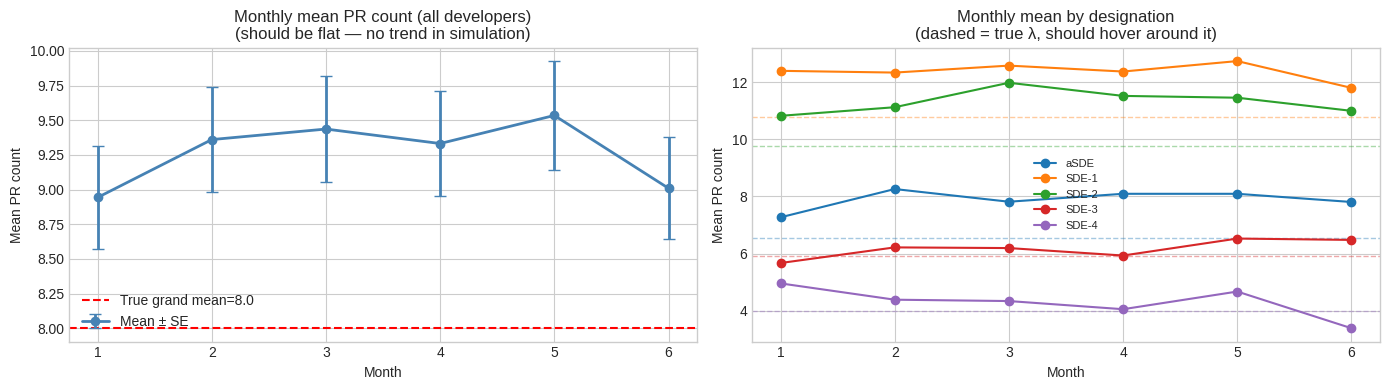

Monthly means (all devs):
month
1    8.943
2    9.361
3    9.437
4    9.332
5    9.535
6    9.009


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: Overall monthly mean
ax = axes[0]
monthly_overall = df.groupby('month')['pr_count'].agg(['mean','std'])
ax.errorbar(monthly_overall.index, monthly_overall['mean'],
            yerr=monthly_overall['std'] / np.sqrt(250),
            fmt='o-', color='steelblue', capsize=4, lw=2, label='Mean ± SE')
ax.axhline(np.exp(MU_ORG), color='red', linestyle='--', lw=1.5,
           label=f'True grand mean={np.exp(MU_ORG):.1f}')
ax.set_xlabel("Month")
ax.set_ylabel("Mean PR count")
ax.set_title("Monthly mean PR count (all developers)\n(should be flat — no trend in simulation)")
ax.set_xticks(range(1, 7))
ax.legend()

# Panel 2: Monthly mean by designation
ax = axes[1]
for i, desig in enumerate(DESIGNATIONS):
    sub = df[df.designation == desig].groupby('month')['pr_count'].mean()
    ax.plot(sub.index, sub.values, marker='o', color=f'C{i}', label=desig, lw=1.5)
    ax.axhline(TRUE_LAM_PER_DESIG[i], color=f'C{i}', linestyle='--', alpha=0.4, lw=1)
ax.set_xlabel("Month")
ax.set_ylabel("Mean PR count")
ax.set_title("Monthly mean by designation\n(dashed = true λ, should hover around it)")
ax.set_xticks(range(1, 7))
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Monthly means (all devs):")
print(df.groupby('month')['pr_count'].mean().round(3).to_string())

## 6. Individual Developer Variance

Check: developers have different rates (between-developer variance is real),
and monthly counts for one developer fluctuate around their personal mean.

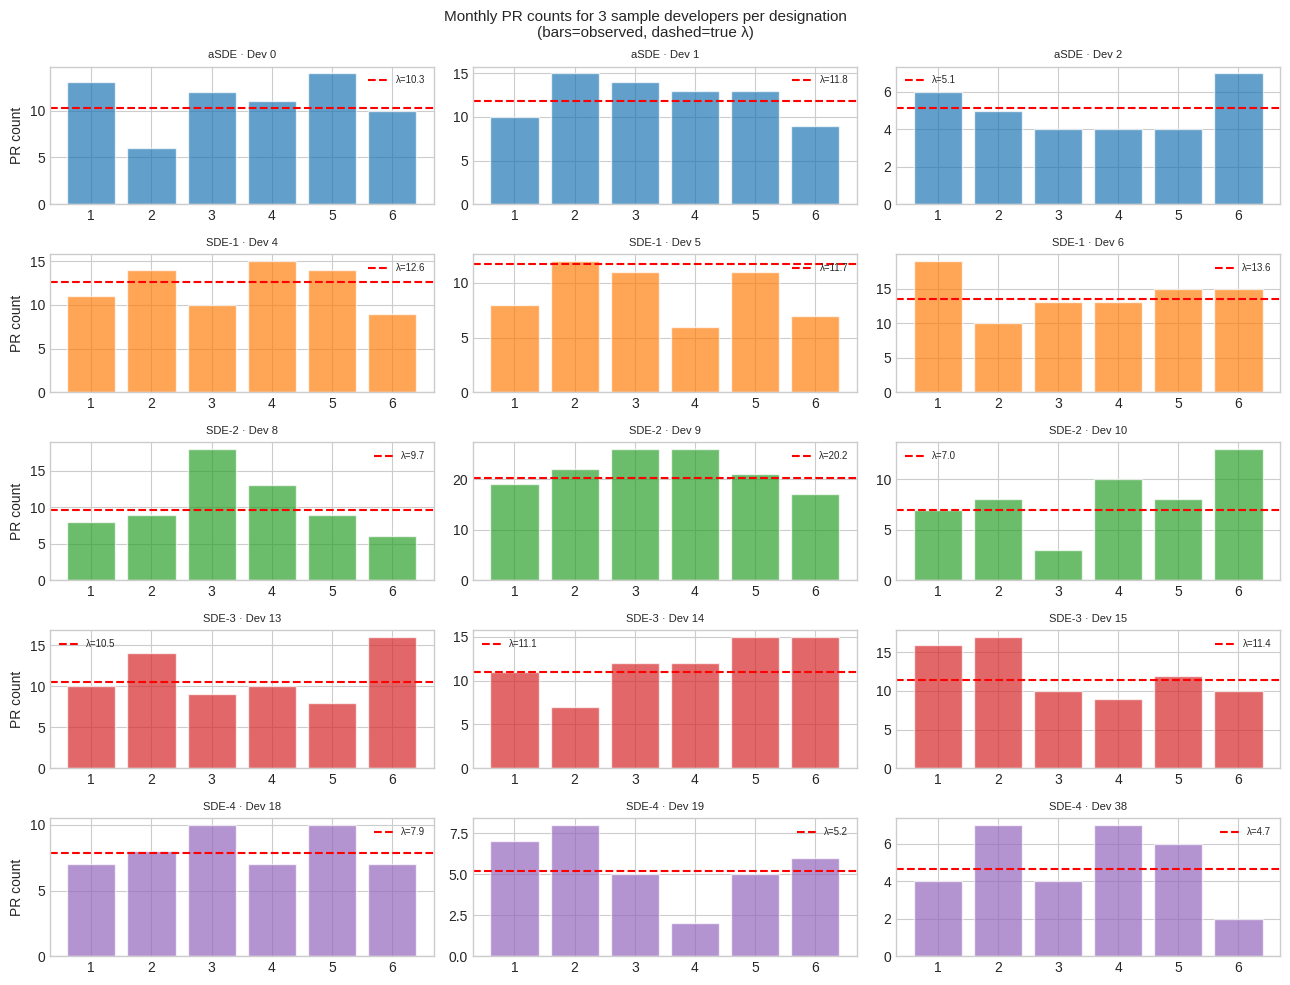

In [7]:
# Pick a sample of developers across designations
sample_devs = []
for desig in DESIGNATIONS:
    devs = df[df.designation == desig]['developer_id'].unique()
    sample_devs.extend(devs[:3])   # 3 per designation = 15 total

fig, axes = plt.subplots(len(DESIGNATIONS), 3, figsize=(13, 10), sharey=False)

for row_idx, desig in enumerate(DESIGNATIONS):
    devs = df[df.designation == desig]['developer_id'].unique()[:3]
    for col_idx, dev_id in enumerate(devs):
        ax = axes[row_idx, col_idx]
        dev_rows = df[df.developer_id == dev_id]
        true_lam = dev_rows['true_lam'].iloc[0]

        ax.bar(dev_rows['month'], dev_rows['pr_count'],
               color=f'C{row_idx}', alpha=0.7, edgecolor='white')
        ax.axhline(true_lam, color='red', linestyle='--', lw=1.5,
                   label=f'λ={true_lam:.1f}')
        ax.set_title(f"{desig} · Dev {dev_id}", fontsize=8)
        ax.set_xticks(range(1, 7))
        if col_idx == 0:
            ax.set_ylabel("PR count")
        ax.legend(fontsize=7)

plt.suptitle("Monthly PR counts for 3 sample developers per designation\n"
             "(bars=observed, dashed=true λ)", fontsize=11)
plt.tight_layout()
plt.show()

## 7. EDA Summary

| Check | Result |
|-------|--------|
| Shape | 1,500 rows (250 devs × 6 months) ✓ |
| Exposure | All 1.0 ✓ |
| Designation counts | 75/63/50/37/25 pyramid ✓ |
| Designation means | Close to true λ values ✓ |
| Var/mean ratio | ≈ 1.0 — Poisson is reasonable ✓ |
| Team variation | Visible spread around grand mean ✓ |
| Monthly trend | Flat — no spurious trend ✓ |
| Developer variation | Clear individual differences ✓ |

**No surprises.** The simulated data behaves exactly as designed.

**Next:** `03_prior_predictive.ipynb` — check that our priors produce sensible counts before fitting.